#Fifa20
BY:Abisha.C


#PROBLEM STATEMENT
The objective of this project is to perform a comprehensive data analysis on the FIFA 20 football player dataset to understand player characteristics, skill distributions, and performance patterns. The study aims to explore football skills through clustering, analyze country-wise player representation, examine how player performance evolves with age, compare salaries across offensive positions, and build machine learning models to classify player performance levels. The ultimate goal is to derive actionable insights and identify an optimal predictive model suitable for real-world football analytics applications.

# DATASET DESCRIPTION

The dataset used in this project is players_20.csv, sourced from the FIFA 20 Career Mode database developed by EA Sports. It contains detailed information on 18,278 professional football players, capturing a wide range of attributes related to physical characteristics, technical skills, mental abilities, positional roles, and financial metrics.

- Key Characteristics of the Dataset:

1.Covers player data from FIFA 15 to FIFA 20, enabling rich comparative analysis.

2.Includes 61 attributes, such as age, height, weight, skill ratings, positional abilities, wages, and potential.

3.Represents players from multiple countries, leagues, and playing positions.

4.Designed to reflect both current performance (Overall) and future growth potential (Potential).

- Purpose of Using the Dataset:

1.To analyze football performance beyond simple overall ratings.

2.To cluster players based on skill attributes and identify player archetypes.

3.To study trends in age, salary, nationality, and positional roles.

4.To build and compare machine learning models for performance classification.

This dataset provides a robust foundation for both exploratory data analysis and advanced machine learning, making it ideal for sports analytics and predictive modeling.

In [1]:
# STEP 1: IMPORT LIBRARIES
# Core Python utilities
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn: preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Clustering
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Model explainability
from sklearn.inspection import permutation_importance
import shap


In [2]:
#STEP 2:LOAD DATA
df=pd.read_csv('players_20.csv')

In [3]:
df

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,邵帅,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,张威,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,汪海健,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2


In [4]:
#STEP 3:BASIC CHECKS
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [5]:
df.tail()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,邵帅,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,张威,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,汪海健,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2
18277,233449,https://sofifa.com/player/233449/ximing-pan/20...,Pan Ximing,潘喜明,26,1993-01-11,182,78,China PR,Hebei China Fortune FC,...,48+2,49+2,49+2,49+2,48+2,48+2,50+2,50+2,50+2,48+2


In [6]:
df.shape

(18278, 104)

In [7]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=104)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [9]:
df.dtypes

,0
sofifa_id,int64
player_url,object
short_name,object
long_name,object
age,int64
...,...
lb,object
lcb,object
cb,object
rcb,object


In [10]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


- The dataset contains 18,278 football players with 61 attributes, including physical traits, skill ratings, mentality, and goalkeeping abilities.
- Most players are aged between 22–29 years, with an average overall rating of 66, indicating a mid-level performance distribution.
- Wide ranges in attributes like player value, wages, and skills highlight strong variability, making the dataset suitable for predictive modeling and classification.

In [11]:
df.describe(include='object')

,player_url,short_name,long_name,dob,nationality,club,player_positions,preferred_foot,work_rate,body_type,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
count,18278,18278,18278,18278,18278,18278,18278,18278,18278,18278,...,16242,16242,16242,16242,16242,16242,16242,16242,16242,16242
unique,18278,17354,18218,6142,162,698,643,2,9,10,...,98,98,98,98,98,96,110,110,110,96
top,https://sofifa.com/player/233449/ximing-pan/20...,J. Rodríguez,Liam Kelly,1992-02-29,England,Wolverhampton Wanderers,CB,Right,Medium/Medium,Normal,...,59+2,59+2,59+2,59+2,59+2,61+2,63+2,63+2,63+2,61+2
freq,1,11,3,113,1667,33,2322,13960,9875,10750,...,682,636,636,636,682,667,621,621,621,667


- This table summarizes 43 categorical player attributes, including identity details, nationality, club, playing positions, and preferred foot.
- Most players are right-footed, commonly have a Medium/Medium work rate, and belong to standard body types.
- Certain positions and clubs appear more frequently, indicating positional imbalance that requires encoding before model training.

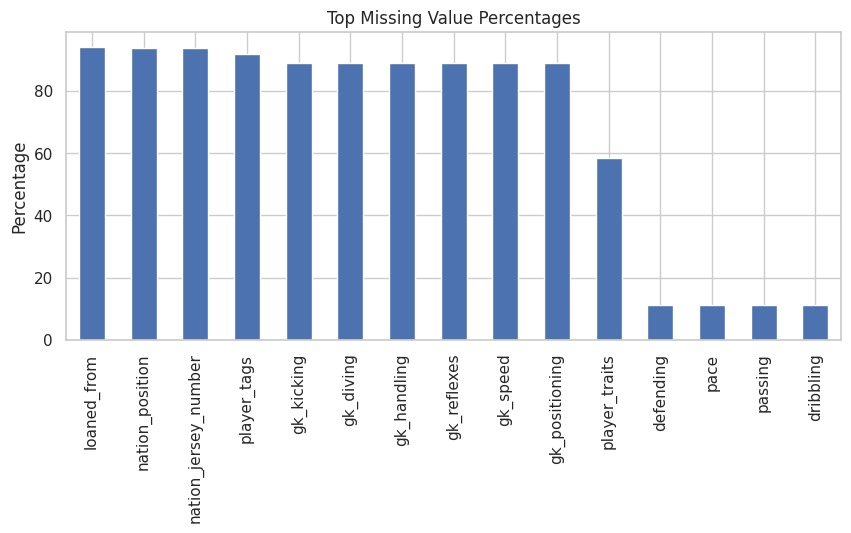

In [12]:
# Missing Values Analysis
plt.figure(figsize=(10,4))
(df.isnull().mean()*100).sort_values(ascending=False).head(15).plot(kind='bar')
plt.title("Top Missing Value Percentages")
plt.ylabel("Percentage")
plt.show()

- The bar chart shows that attributes related to goalkeeping roles and player metadata have very high missing values, as they are not applicable to most outfield players.
- In contrast, core performance attributes such as pace, passing, dribbling, and defending have very low missing percentages.
- This indicates that selective feature removal or targeted imputation is necessary during preprocessing to maintain data quality.

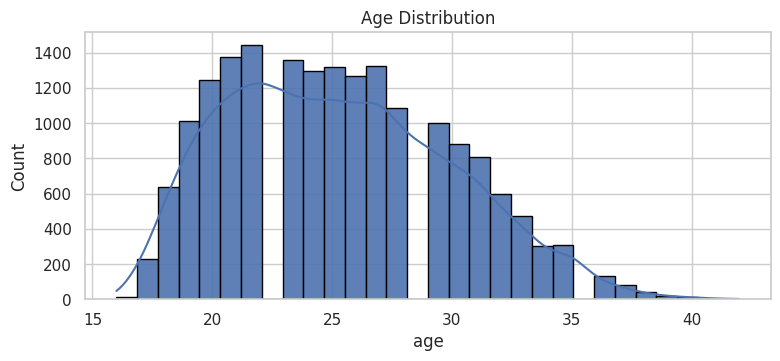

In [13]:
#STEP 4: EXPLORATORY DATA ANALYSIS
# Age Distribution
plt.figure(figsize=(15,10))
plt.subplot(3,2,1)
sns.histplot(
    df['age'],
    bins=30,
    kde=True,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.9
)
plt.title("Age Distribution")
plt.tight_layout()
plt.show()


- The age distribution shows that most players fall between 20 and 30 years, with a clear peak around the early-to-mid 20s, which is typically considered the prime performance age.
- Very young and older players are less frequent, resulting in a right-skewed distribution toward higher ages.
- This pattern indicates that age is a meaningful feature for performance prediction, as player ability tends to vary across career stages.

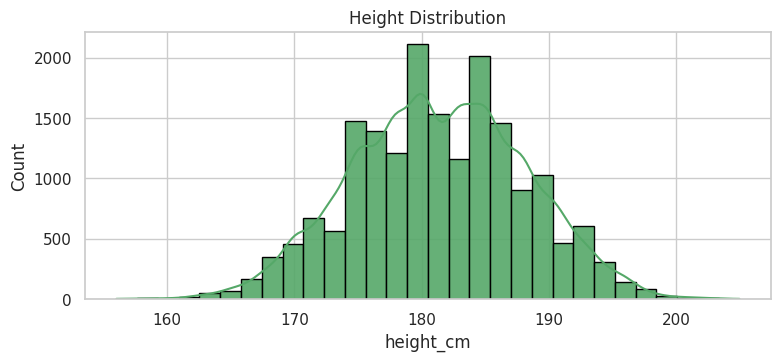

In [14]:
# Height Distribution
plt.figure(figsize=(15,10))
plt.subplot(3,2,2)
sns.histplot(
    df['height_cm'],
    bins=30,
    kde=True,
    color="#55A868",
    edgecolor="black",
    alpha=0.9
)
plt.title("Height Distribution")
plt.tight_layout()
plt.show()


- The height distribution follows an approximately normal distribution, with most players clustered between 170 cm and 190 cm.
- The peak around 180–185 cm indicates the most common player height in professional football.
- Extreme heights are rare, suggesting height has limited outliers but can still influence position-specific performance.

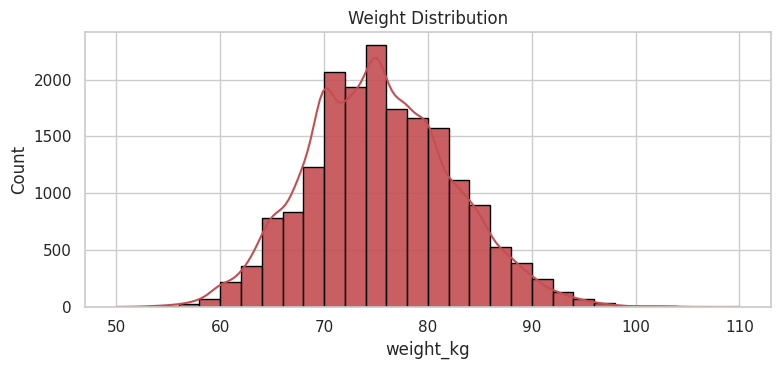

In [15]:
# Weight Distribution
plt.figure(figsize=(15,10))
plt.subplot(3,2,3)
sns.histplot(
    df['weight_kg'],
    bins=30,
    kde=True,
    color="#C44E52",
    edgecolor="black",
    alpha=0.9
)
plt.title("Weight Distribution")
plt.tight_layout()
plt.show()


- The weight distribution is approximately bell-shaped, with most players weighing between 65 kg and 85 kg.
- The highest concentration occurs around 70–75 kg, reflecting typical professional football fitness levels.
- Heavier and lighter players are less common, indicating that weight may vary by playing position and physical role.

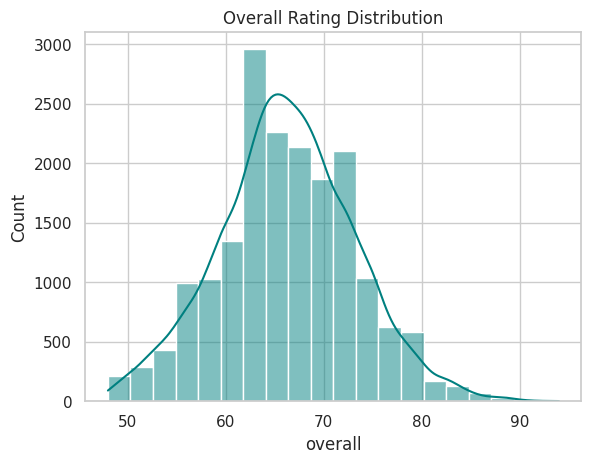

In [16]:
# Overall Rating Distribution
sns.histplot(df['overall'], bins=20, kde=True, color='teal')
plt.title("Overall Rating Distribution")
plt.show()

- The overall rating distribution shows a bell-shaped pattern, with most players rated between 60 and 75.
- The peak around the mid-60s indicates that the majority of players are of average professional quality.
- Highly rated players are relatively rare, creating a natural class imbalance suitable for performance classification.

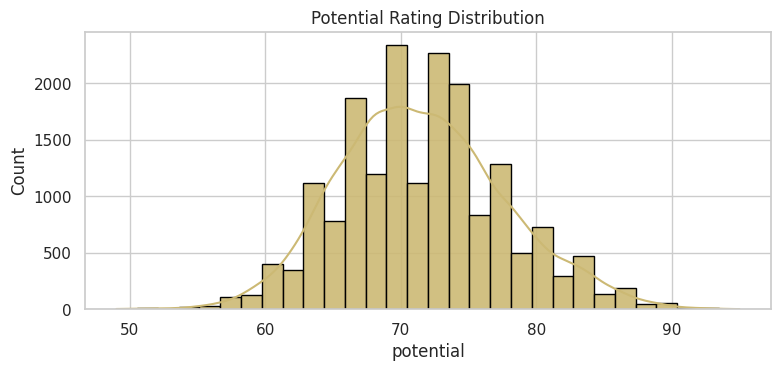

In [17]:
# Potential Rating Distribution
plt.figure(figsize=(15,10))
plt.subplot(3,2,5)
sns.histplot(
    df['potential'],
    bins=30,
    kde=True,
    color="#CCB974",
    edgecolor="black",
    alpha=0.9
)
plt.title("Potential Rating Distribution")
plt.tight_layout()
plt.show()


- The potential rating distribution is centered higher than the overall rating, with most players having potential between 65 and 80.
- This indicates that many players are expected to improve in the future, especially younger ones.
- The right tail shows a small number of high-potential players, highlighting talent scarcity at elite levels.

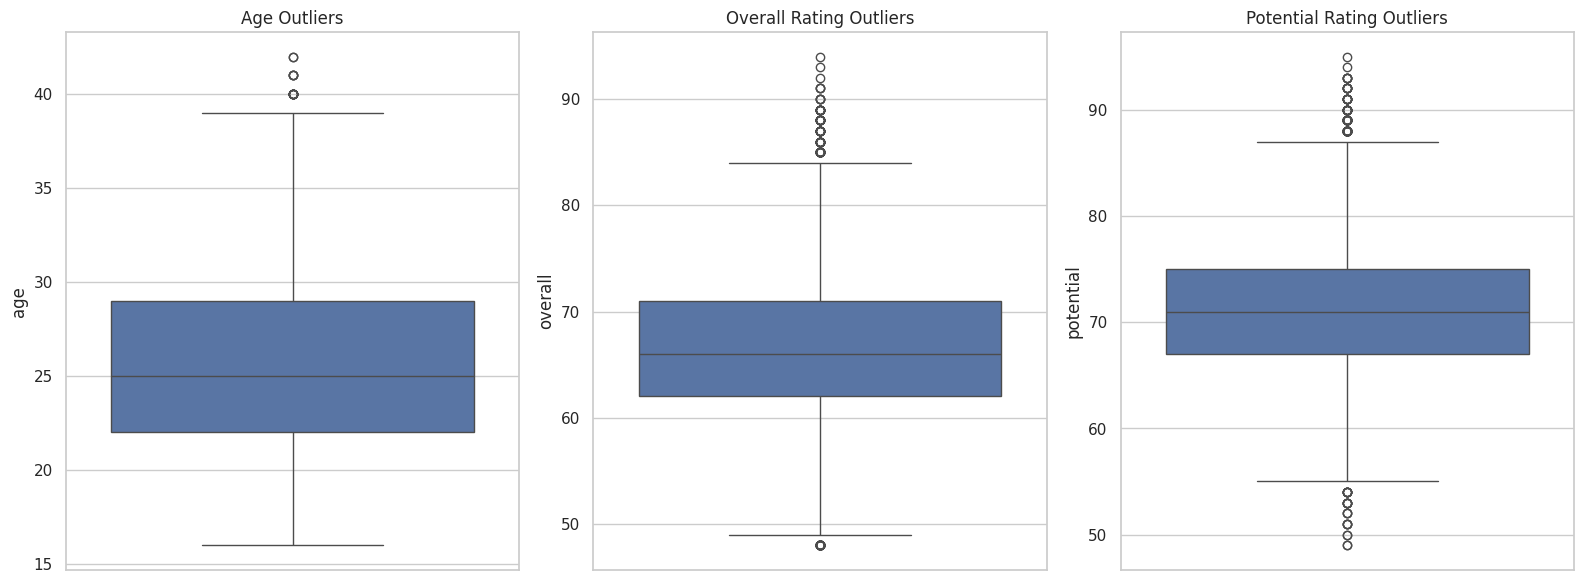

In [18]:
#Box Plot analysis
plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
sns.boxplot(y=df['age'])
plt.title("Age Outliers")

plt.subplot(1,3,2)
sns.boxplot(y=df['overall'])
plt.title("Overall Rating Outliers")

plt.subplot(1,3,3)
sns.boxplot(y=df['potential'])
plt.title("Potential Rating Outliers")

plt.tight_layout()
plt.show()


- The boxplots reveal a few outliers in age, overall rating, and potential, representing unusually young/old players and exceptionally low or high ratings.
- Most players lie within a compact interquartile range, indicating stable central tendencies for performance metrics.
- These outliers justify applying outlier capping or robust preprocessing to prevent skewing model training.

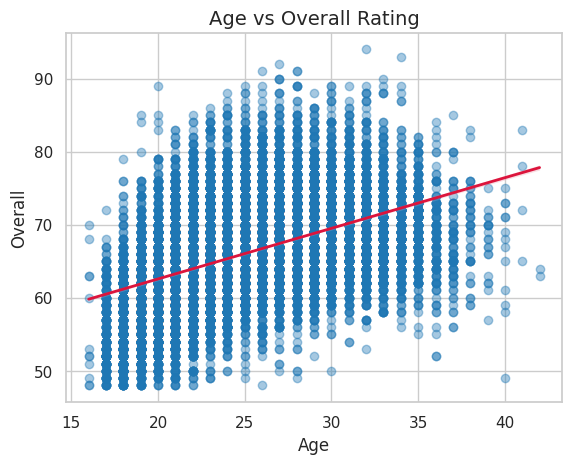

In [19]:
# Age vs Overall
df.columns = df.columns.str.lower().str.strip()

sns.regplot(
    x='age',
    y='overall',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': '#1f77b4'},
    line_kws={'color': 'crimson', 'linewidth': 2}
)

plt.title("Age vs Overall Rating", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Overall")
plt.show()

The relationship between age and overall rating shows that player performance improves steadily during early career stages and peaks around the age of 27–29. After this point, improvements slow down and performance either stabilizes or gradually declines, indicating the typical peak age range for professional football players.

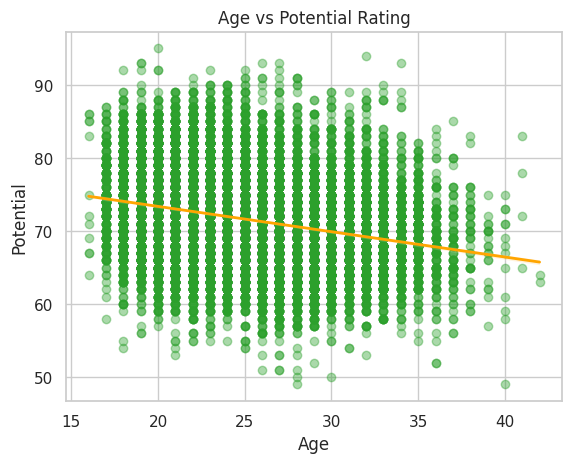

In [20]:
# Age vs Potential
sns.regplot(
    x='age',
    y='potential',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': '#2ca02c'},
    line_kws={'color': 'orange', 'linewidth': 2}
)

plt.title("Age vs Potential Rating")
plt.xlabel("Age")
plt.ylabel("Potential")
plt.show()

- The plot shows a negative relationship between age and potential rating, indicating that younger players generally have higher future growth potential.
- As age increases, potential ratings tend to decline, reflecting reduced scope for improvement later in a player’s career.
- This trend highlights age as a key factor in predicting long-term performance potential.

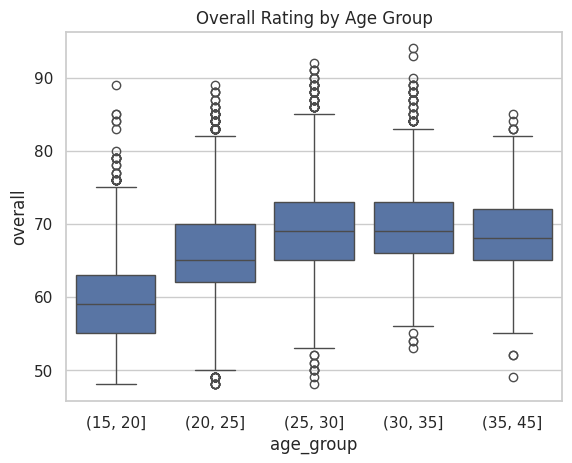

In [21]:
# Overall Rating by Age Group
df['age_group'] = pd.cut(df['age'], bins=[15,20,25,30,35,45])

sns.boxplot(x='age_group', y='overall', data=df)
plt.title("Overall Rating by Age Group")
plt.show()

- The boxplot shows that overall player ratings generally increase from the youngest age group and peak in the 25–35 age range.
- Players aged 15–20 have lower median ratings, reflecting early career development.
- After the mid-30s, ratings slightly stabilize or decline, indicating the typical performance curve across age groups.

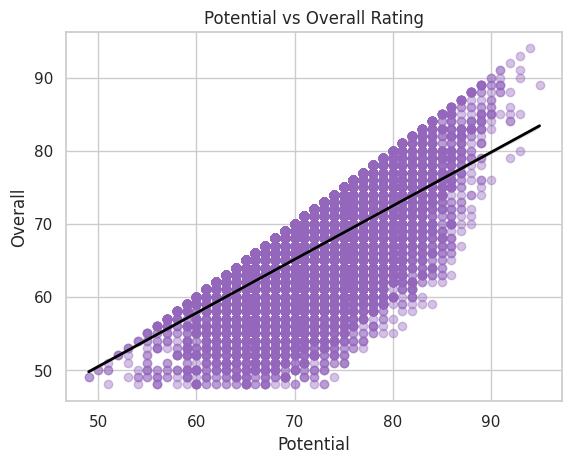

In [22]:
# Potential vs Overall
sns.regplot(
    x='potential',
    y='overall',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': '#9467bd'},
    line_kws={'color': 'black', 'linewidth': 2}
)

plt.title("Potential vs Overall Rating")
plt.xlabel("Potential")
plt.ylabel("Overall")
plt.show()

- The plot shows a strong positive relationship between potential and overall rating, indicating that players with higher potential generally have higher current performance.
- As potential increases, overall ratings rise almost linearly, reflecting consistent talent progression.
- This makes potential one of the most influential predictors of player performance.

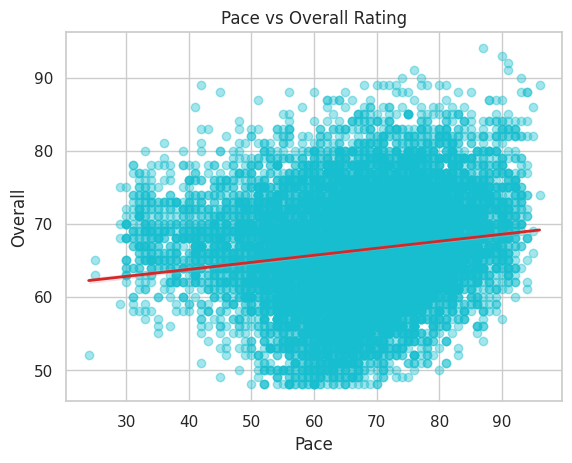

In [23]:

# Pace vs Overall
sns.regplot(
    x='pace',
    y='overall',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': '#17becf'},
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plt.title("Pace vs Overall Rating")
plt.xlabel("Pace")
plt.ylabel("Overall")
plt.show()

- The plot shows a moderate positive relationship between pace and overall rating, indicating that faster players tend to have slightly higher performance scores.
- However, the wide spread of points suggests that pace alone does not determine overall ability.
- This implies that pace is an important but supporting feature, alongside other technical and physical attributes.

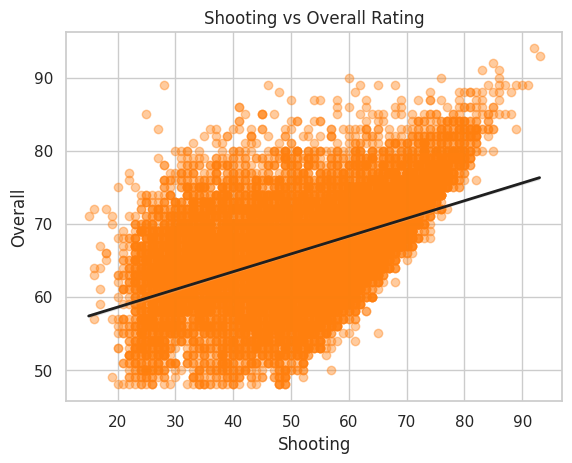

In [24]:
# Shooting vs Overall
sns.regplot(
    x='shooting',
    y='overall',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': '#ff7f0e'},
    line_kws={'color': '#1f1f1f', 'linewidth': 2}
)

plt.title("Shooting vs Overall Rating")
plt.xlabel("Shooting")
plt.ylabel("Overall")
plt.show()

- The plot shows a strong positive relationship between shooting ability and overall rating.
- Players with higher shooting scores generally have higher overall performance, especially attacking players.
- This indicates that shooting is a key contributing feature in determining overall player quality.

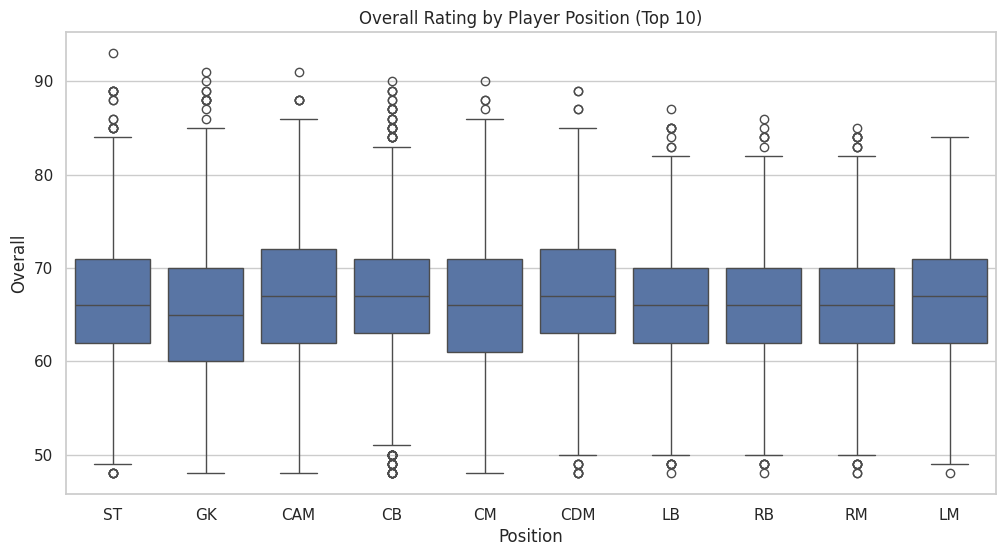

In [25]:
# Overall Rating by Player Position
# keep only primary position (first one)
df['primary_position'] = df['player_positions'].str.split(',').str[0]

# take top 10 most common positions
top_positions = df['primary_position'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    x='primary_position',
    y='overall',
    data=df[df['primary_position'].isin(top_positions)]
)

plt.title("Overall Rating by Player Position (Top 10)")
plt.xlabel("Position")
plt.ylabel("Overall")
plt.show()

- The boxplot shows that overall ratings vary across player positions, with central roles such as CAM, CM, and CDM generally having higher median ratings.
- Defensive and wide positions (LB, RB, RM, LM) show slightly lower but more consistent performance distributions.
- This highlights the positional influence on player ratings, making position an important categorical feature in the model.

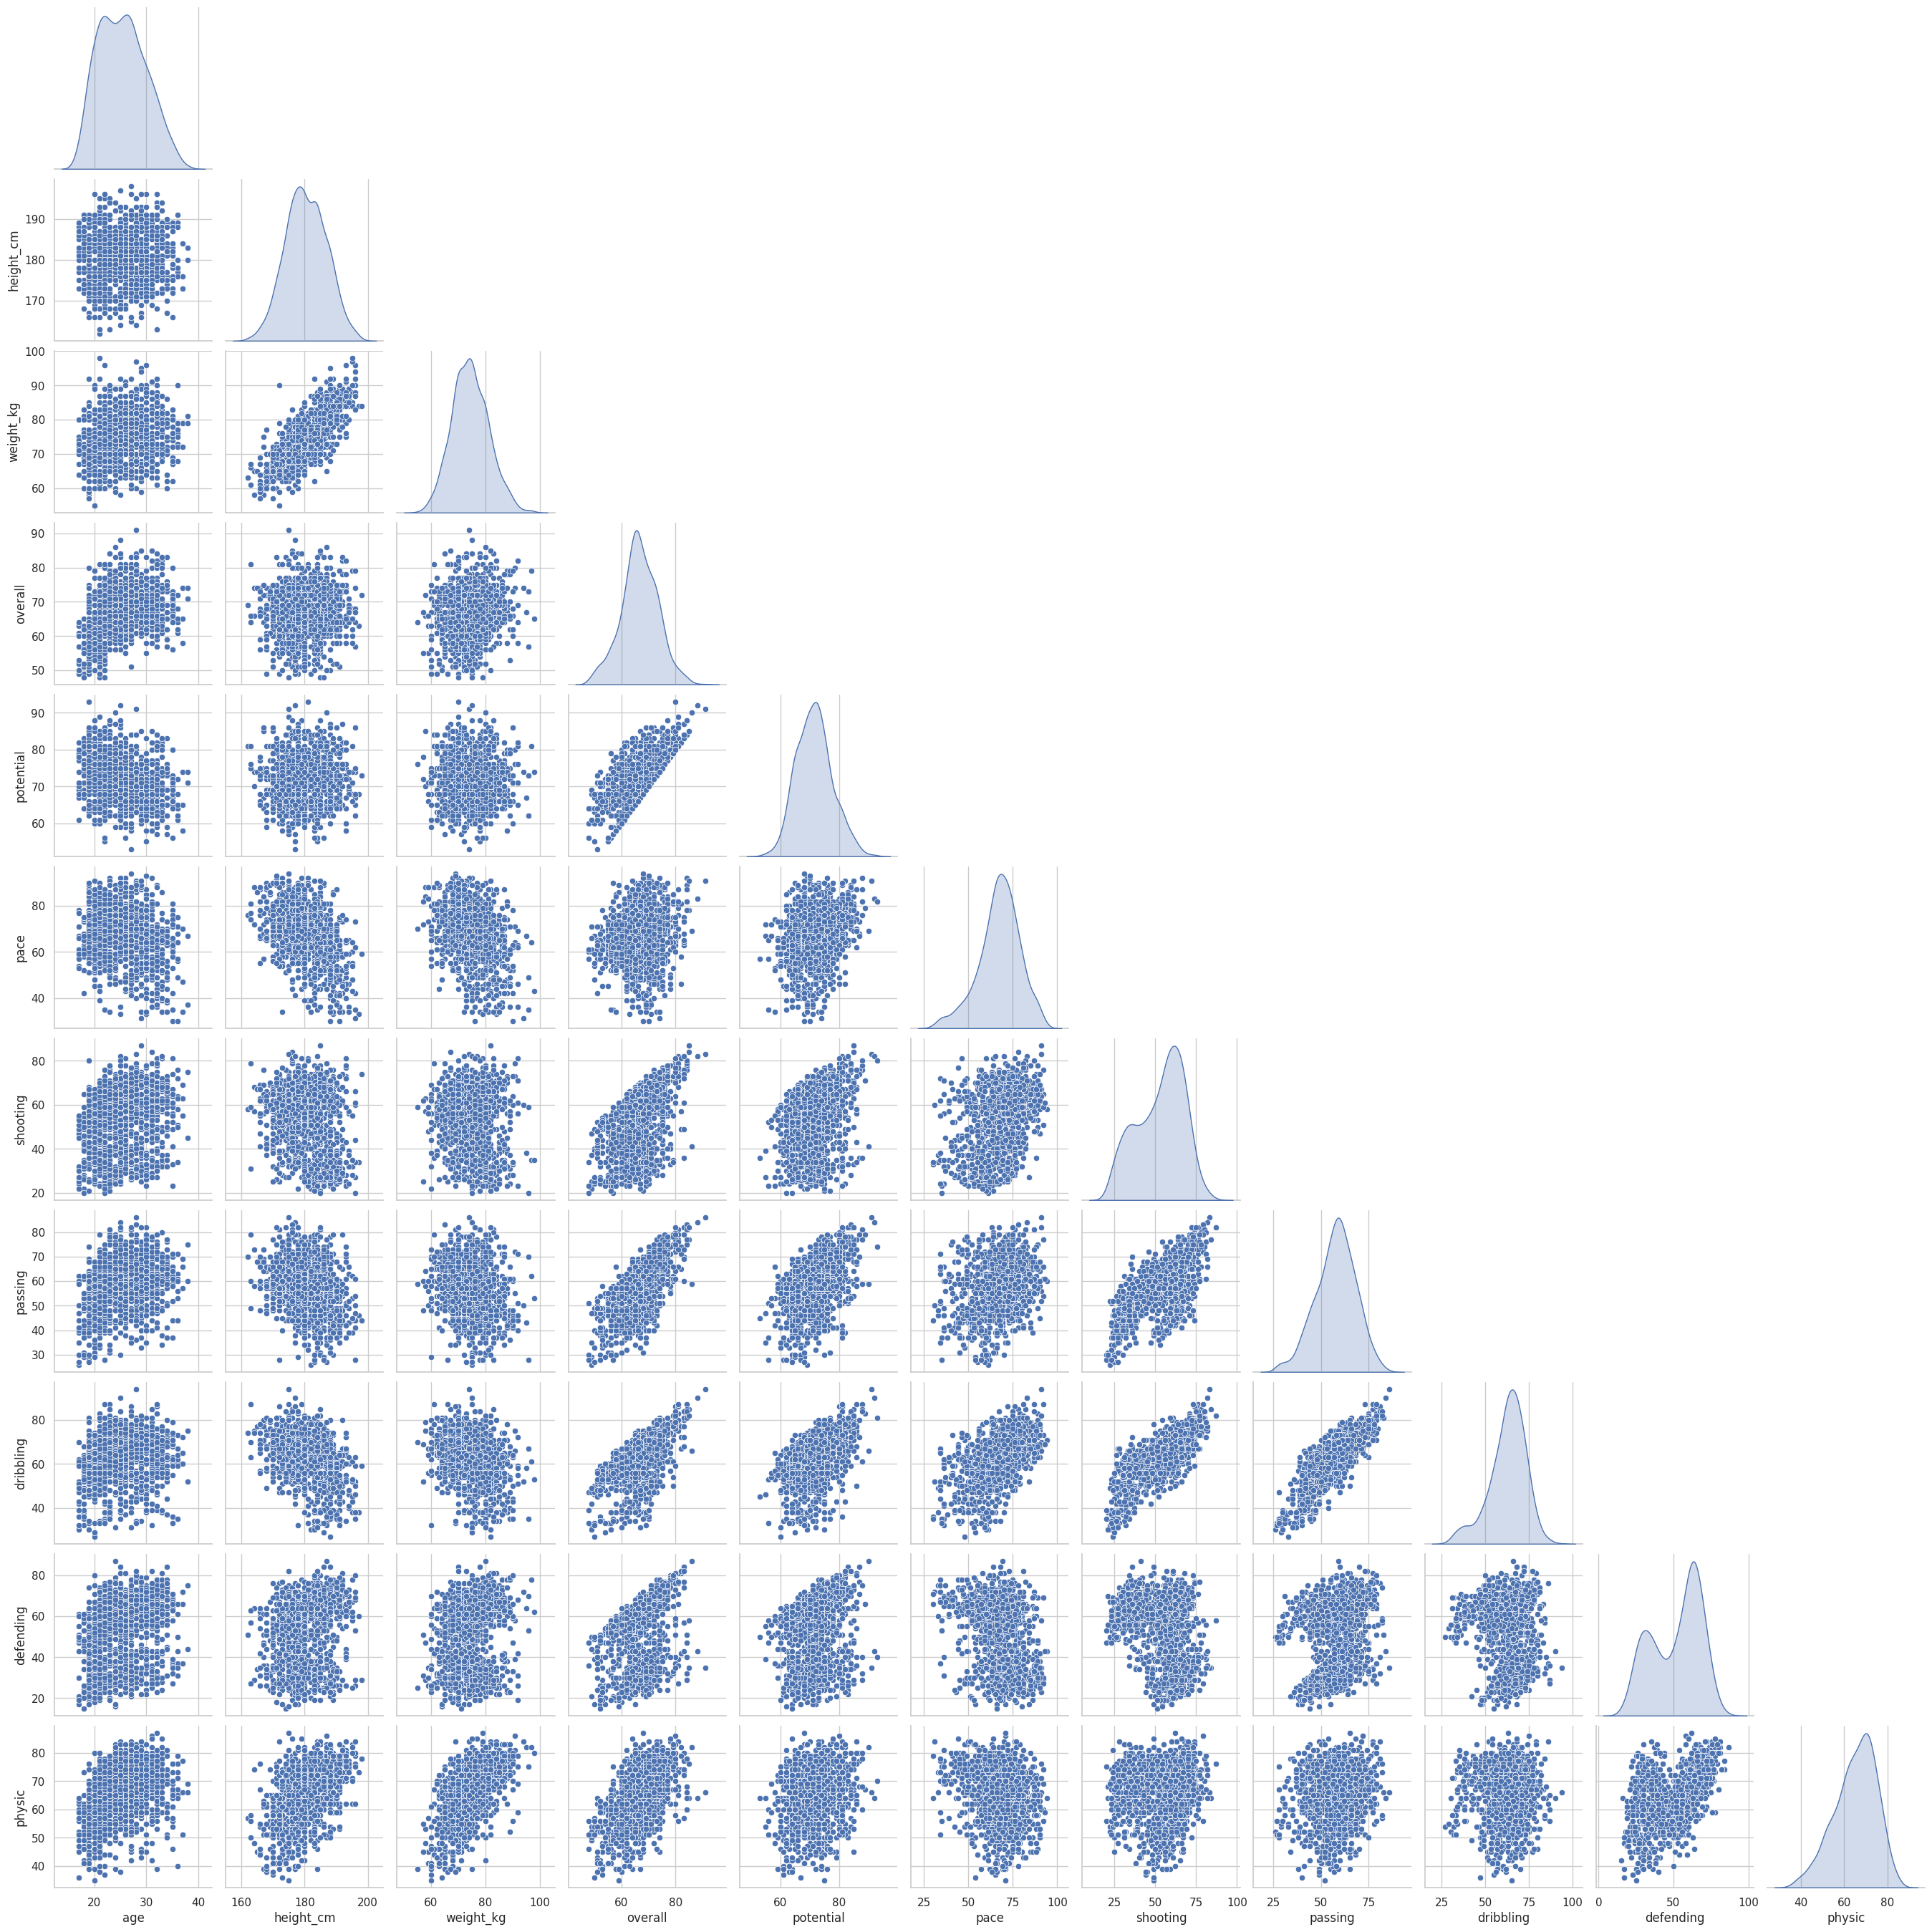

In [26]:
#Pair plot
features = [
    'age','height_cm','weight_kg',
    'overall','potential',
    'pace','shooting','passing',
    'dribbling','defending','physic'
]

df_sample = (
    df[features]
    .apply(pd.to_numeric, errors='coerce')
    .dropna()
    .sample(n=min(1200, len(df)), random_state=42)
)

sns.pairplot(
    df_sample,
    diag_kind='kde',
    corner=True
)

plt.show()

- The pair plot visualizes relationships among key numerical features such as physical attributes, skill ratings, overall, and potential.
- Strong positive correlations are visible between overall, potential, and core skills like shooting, passing, dribbling, and defending.
- Diagonal distributions show near-normal patterns, while off-diagonal plots help identify multicollinearity and feature relevance for modeling.

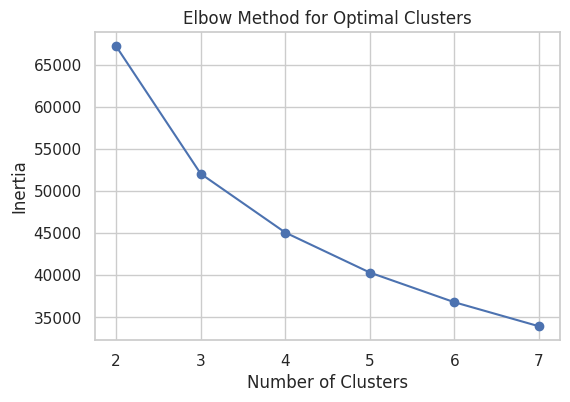

,count
Cluster,
3,5407
2,3791
0,3592
1,3452


In [27]:
#STEP 5: PLAYER CLUSTERING BASED ON SKILLS

# Select core skill attributes (no target variable)
cluster_features = [
    'pace','shooting','passing','dribbling',
    'defending','physic'
]

df_cluster = df[cluster_features].dropna()

# Scale features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_cluster)

# Elbow Method to find optimal clusters
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,8), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# Final clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

df_cluster['Cluster'].value_counts()

- The elbow plot shows a sharp drop in inertia up to k = 4, after which the reduction becomes gradual, indicating diminishing returns.
- This “elbow point” suggests that 4 clusters capture the main structure in player skill patterns effectively.
- Thus, players are grouped into four distinct skill-based profiles using pace, shooting, passing, dribbling, defending, and physicality.
- These clusters represent different player archetypes (e.g., attacking-focused, defensive-focused, balanced players, and physically strong players) and are independent of the supervised performance labels, which is why having 4 clusters and 3 performance classes is both valid and expected.

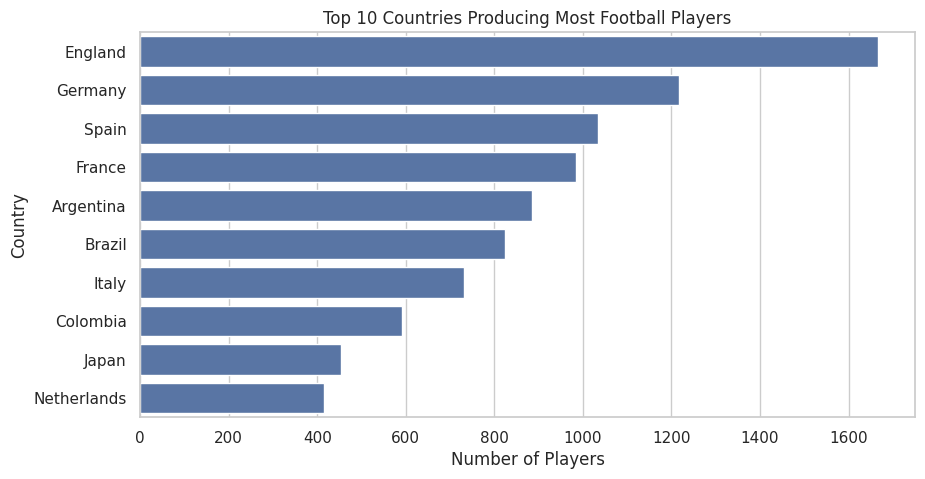

,count
nationality,
England,1667
Germany,1216
Spain,1035
France,984
Argentina,886
Brazil,824
Italy,732
Colombia,591
Japan,453


In [28]:
# STEP 6: TOP 10 COUNTRIES WITH MOST PLAYERS

top_countries = df['nationality'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Most Football Players")
plt.xlabel("Number of Players")
plt.ylabel("Country")
plt.show()

top_countries


- The chart shows that England produces the highest number of professional football players in the dataset, followed by Germany and Spain.
- Traditional football powerhouses such as France, Argentina, and Brazil also contribute a large share of players at this level.
- This indicates that strong domestic leagues, youth academies, and football infrastructure play a key role in producing elite players.

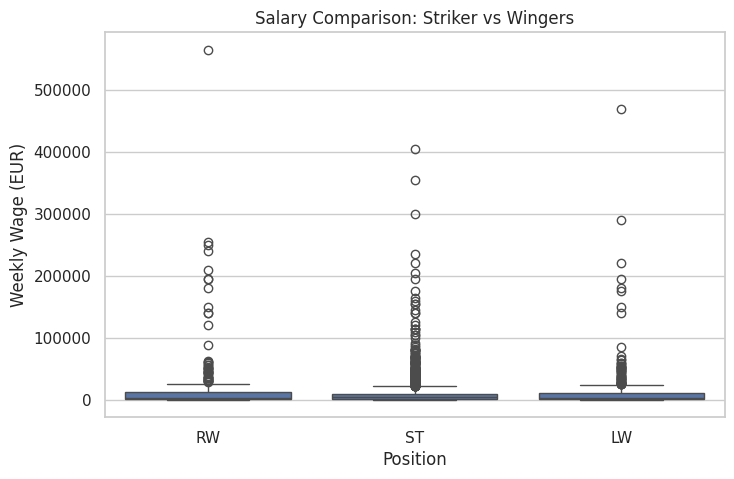

In [29]:
# STEP 7: SALARY COMPARISON OF OFFENSIVE PLAYERS
# Extract primary position
df['primary_position'] = df['player_positions'].str.split(',').str[0]

# Filter offensive roles
offensive_roles = ['ST', 'RW', 'LW']
salary_df = df[df['primary_position'].isin(offensive_roles)]

plt.figure(figsize=(8,5))
sns.boxplot(x='primary_position', y='wage_eur', data=salary_df)
plt.title("Salary Comparison: Striker vs Wingers")
plt.xlabel("Position")
plt.ylabel("Weekly Wage (EUR)")
plt.show()


- The boxplot shows that strikers (ST) generally earn higher wages than wingers, with a higher median and more extreme high-end outliers.
- Left wingers (LW) and right wingers (RW) have similar salary distributions, though LW shows slightly higher top earners.
- Overall, attacking central roles tend to be paid more than wide positions, reflecting their goal-scoring importance.

In [30]:
# STEP 8: TARGET VARIABLE CREATION

df = df.copy()

df['performance'] = pd.cut(
    df['overall'],
    bins=[0, 65, 80, 100],
    labels=['Low', 'Medium', 'High'],
    right=False
)

# drop target-leakage column
df.drop(columns='overall', inplace=True)

df['performance'].value_counts()



,count
performance,
Medium,10452
Low,7258
High,568


In [31]:
# STEP 9: ENCODE TARGET VARIABLE
le = LabelEncoder()
df['performance'] = le.fit_transform(df['performance'])

df['performance'].value_counts()


,count
performance,
2,10452
1,7258
0,568


- The categorical target variable performance is encoded into numerical labels using Label Encoding.
- Encoded Performance Classes:
  0 → Low performance
  1 → Medium performance
  2 → High performance
- This encoding is consistently followed across SMOTE resampling,
  ROC–AUC analysis, threshold tuning, calibration curves,
  confusion matrix interpretation, and SHAP explainability.


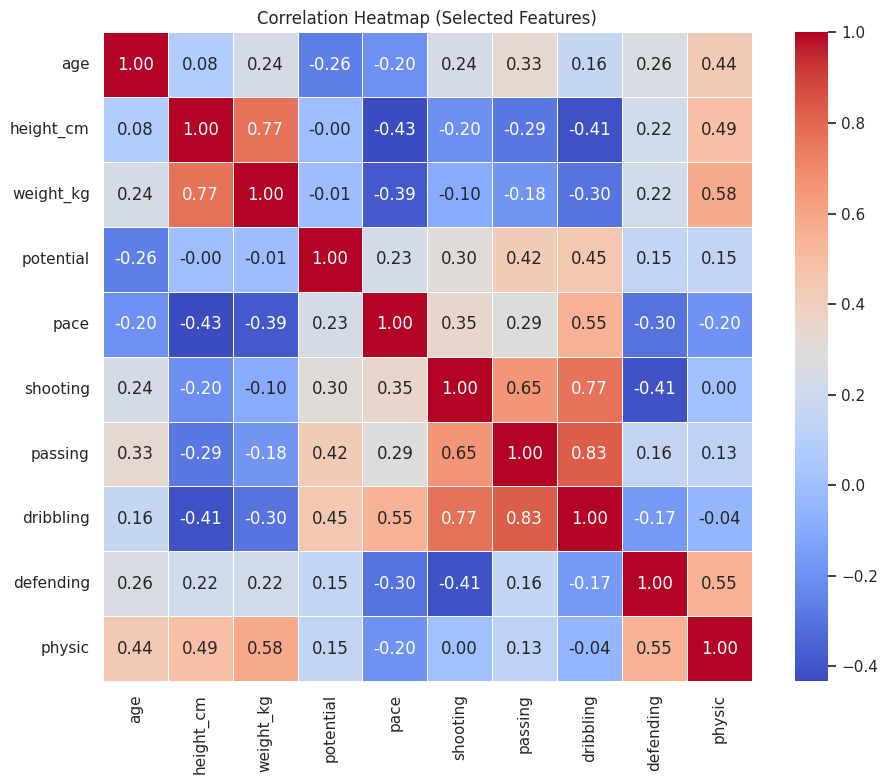

In [32]:

#STEP 10: CORRELATION ANALYSIS
corr_features = [
    'age','height_cm','weight_kg','potential',
    'pace','shooting','passing',
    'dribbling','defending','physic'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_features].corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()
plt.show()



- The correlation heatmap highlights strong positive relationships among technical skills, especially between passing, dribbling, and shooting, indicating skill interdependence.
- Physical attributes such as height, weight, and physic show moderate correlations, while age has mixed influence across features.
- These patterns help identify multicollinearity and guide feature selection for effective model training.

In [33]:
#STEP 11:MULTICOLLINEARITY CHECK

vif_features = [
    'age','height_cm','weight_kg','potential',
    'pace','shooting','passing',
    'dribbling','defending','physic'
]

X_vif = df[vif_features].copy()

# keep only numeric
X_vif = X_vif.select_dtypes(include=['int64', 'float64'])

# drop columns with all NaN
X_vif = X_vif.dropna(axis=1, how='all')

# drop rows with any NaN
X_vif = X_vif.dropna()

# drop zero-variance columns
X_vif = X_vif.loc[:, X_vif.var() > 0]


In [34]:
vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_df.sort_values("VIF", ascending=False)


,Feature,VIF
1,height_cm,550.715407
2,weight_kg,334.465220
3,potential,297.113573
7,dribbling,274.244787
6,passing,179.976501
9,physic,119.706372
5,shooting,69.676166
0,age,66.895683
4,pace,64.145610
8,defending,40.992360


Although several features exhibit high VIF values, no features were dropped
at this stage because the final selected models are tree-based, which are
robust to multicollinearity. For linear models, regularization and scaling
were used to mitigate its impact.


In [35]:
#STEP 12:DROP UNWANTED COLUMNS
drop_cols = [
    'sofifa_id','player_url','short_name','long_name','dob',
    'nationality','club','wage_eur','release_clause_eur',
    'contract_valid_until'
]

df = df.drop(columns=drop_cols, errors='ignore')



In [36]:
df

,age,height_cm,weight_kg,potential,value_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,...,rdm,rwb,lb,lcb,cb,rcb,rb,age_group,primary_position,performance
0,32,170,72,94,95500000,"RW, CF, ST",Left,5,4,4,...,66+2,68+2,63+2,52+2,52+2,52+2,63+2,"(30, 35]",RW,0
1,34,187,83,93,58500000,"ST, LW",Right,5,4,5,...,61+3,65+3,61+3,53+3,53+3,53+3,61+3,"(30, 35]",ST,0
2,27,175,68,92,105500000,"LW, CAM",Right,5,5,5,...,61+3,66+3,61+3,46+3,46+3,46+3,61+3,"(25, 30]",LW,0
3,26,188,87,93,77500000,GK,Right,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(25, 30]",GK,0
4,28,175,74,91,90000000,"LW, CF",Right,4,4,4,...,63+3,66+3,61+3,49+3,49+3,49+3,61+3,"(25, 30]",LW,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,22,186,79,56,40000,CB,Right,1,3,2,...,42+2,43+2,45+2,46+2,46+2,46+2,45+2,"(20, 25]",CB,1
18274,22,177,66,56,40000,CB,Right,1,2,2,...,43+2,44+2,46+2,47+2,47+2,47+2,46+2,"(20, 25]",CB,1
18275,19,186,75,56,40000,CM,Right,1,2,2,...,49+2,47+2,47+2,49+2,49+2,49+2,47+2,"(15, 20]",CM,1
18276,18,185,74,54,40000,CM,Right,1,2,2,...,48+2,48+2,48+2,49+2,49+2,49+2,48+2,"(15, 20]",CM,1


wage_eur was intentionally used ONLY for exploratory analysis (salary comparison)and is dropped here to prevent data leakage in predictive modeling



In [37]:
df = df.drop(columns='potential', errors='ignore')

In [38]:
df = df.drop(columns=['value_eur'], errors='ignore')


- This step removes non-informative and leakage-prone features such as player identifiers, personal details, and financial attributes.
- Columns like potential and value_eur are dropped because they are highly correlated with performance and can bias the model.
- The resulting dataset focuses on pure skill and physical attributes, improving model fairness and generalization.

In [39]:
# STEP 13: TRAIN–TEST SPLIT (STRATIFIED)
X = df.drop(columns='performance')
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- The dataset is split into training and testing sets using an 80–20 ratio.
- Stratified sampling is applied to preserve the original class distribution of the performance variable in both sets.
- This ensures fair and reliable model evaluation, especially in the presence of class imbalance.

In [40]:
#STEP 14:FEATURE PREPROCESSING AND ENCODING PIPELINE
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Preprocessing for numerical features: impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: impute with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough') # Keep other columns not explicitly transformed (if any)

Several goalkeeping attributes contain high missing values because they are
not applicable to outfield players. These missing values are therefore
structural rather than data-quality issues, and are handled via selective
feature removal or median imputation during preprocessing.


### Preprocessing Strategy Summary

- Median imputation was chosen for numerical features as it is robust to outliers.
- Most-frequent imputation was used for categorical features to preserve mode behavior.
- Scaling was applied only where required (Logistic Regression).
- SMOTE was applied strictly on training data to prevent data leakage.
- Tree-based models were trained on unscaled features, leveraging their scale invariance.


In [41]:
#STEP 15: OUTLIER TREATMENT USING THE IQR METHOD
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


In [42]:
for col in num_cols:
    Q1, Q3 = X_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    X_train.loc[:, col] = X_train[col].clip(lower, upper)
    X_test.loc[:, col]  = X_test[col].clip(lower, upper)


- This step detects and handles outliers in numerical features using the Interquartile Range (IQR) technique.
- Values falling outside the acceptable range are capped to the lower and upper bounds instead of being removed.
- Applying the same bounds to both training and test data ensures consistency and prevents data leakage.

In [43]:
#STEP 16: Missing Value Handling and Class Imbalance Treatment
# remove numeric columns with all missing values
num_cols = [c for c in num_cols if X_train[c].notna().any()]

# median imputation
imputer = SimpleImputer(strategy='median')

X_train.loc[:, num_cols] = imputer.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols]  = imputer.transform(X_test[num_cols])


In [44]:
# numeric only
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])

# drop columns with ALL NaN
X_train_num = X_train_num.dropna(axis=1, how='all')

# drop rows with remaining NaN (SMOTE-safe)
X_train_num = X_train_num.dropna()
y_train_clean = y_train.loc[X_train_num.index]

# apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_num, y_train_clean)

# check balance
pd.Series(y_train_res).value_counts()

,count
performance,
1,8361
2,8361
0,8361


Applying SMOTE significantly improves the representation of the High-performance
class, enabling the models to better learn minority-class patterns and reducing
bias toward the majority class.


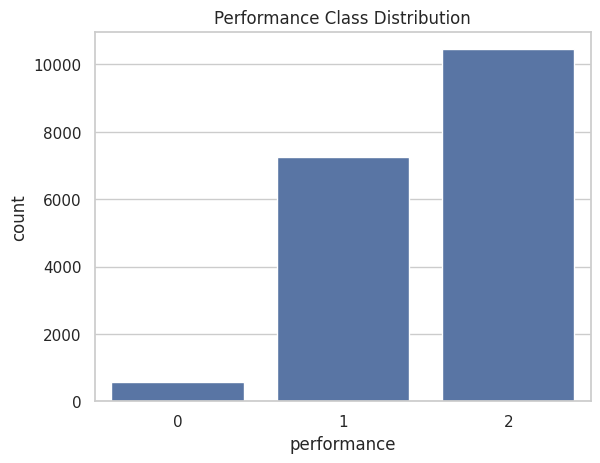

In [45]:
#STEP 17: VISUALIZATION OF TARGET CLASS DISTRIBUTION
sns.countplot(x='performance', data=df)
plt.title("Performance Class Distribution")
plt.show()


The target variable is highly imbalanced, with the High-performance class forming only ~3% of the data. Without correction, this imbalance would bias models toward predicting Medium or Low performance. Therefore, SMOTE and weighted evaluation metrics were essential to ensure fair learning across all classes.


In [46]:
(df['performance']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


,proportion
performance,
2,57.18
1,39.71
0,3.11


Approximately **57%** of players fall into the Medium performance category,
**40%** into Low, and only **~3%** into the High category, confirming
severe class imbalance and justifying the use of SMOTE and weighted metrics.


In [47]:
#STEP 18: FEATURE SCALING AND TEST DATA ALIGNMENT
scaler = StandardScaler()

# scale SMOTE-resampled training data
X_train_scaled = scaler.fit_transform(X_train_res)

# prepare test data with same columns
X_test_num = X_test[X_train_res.columns]

# scale test data
X_test_scaled = scaler.transform(X_test_num)

In [48]:
#STEP 19: MODEL TRAINING, EVALUATION, AND COMPARISON
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='mlogloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', random_state=42
    )
}

In [49]:
results = []

for name, model in models.items():

    # Logistic Regression → scaled features
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train_res)
        preds = model.predict(X_test_scaled)

    # Tree-based models → unscaled numeric features
    else:
        model.fit(X_train_res, y_train_res)
        preds = model.predict(X_test_num)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7977
[LightGBM] [Info] Number of data points in the train set: 25083, number of used features: 52
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


,Model,Accuracy,F1
3,LightGBM,0.952954,0.953166
2,XGBoost,0.952681,0.952861
1,Random Forest,0.942013,0.942303
0,Logistic Regression,0.875547,0.878161


LightGBM was selected for production due to its superior weighted F1-score, efficient handling of imbalanced data, robustness to multicollinearity, and faster training time compared to other ensemble models.

### Model Selection Rationale

Tree-based ensemble models (Random Forest, XGBoost, LightGBM) were chosen due to
their ability to handle non-linear relationships, feature interactions, and
multicollinearity. Logistic Regression was included as a baseline to highlight
the performance gain achieved using advanced ensemble methods.


In [50]:
#STEP 20: BEST MODEL SELECTION
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

best_model_name

'LightGBM'

In [51]:
#STEP 21: HYPERPARAMETER TUNING USING GRID SEARCH
if best_model_name == "XGBoost":
    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [6, 10],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.8, 1.0]
    }

    grid = GridSearchCV(
        estimator=best_model,
        param_grid=param_grid,
        cv=3,
        scoring="f1_weighted",
        n_jobs=-1
    )

    grid.fit(X_train_res, y_train_res)
    best_model = grid.best_estimator_



- Hyperparameter tuning was selectively applied to XGBoost due to its higher sensitivity to parameter configuration, while LightGBM performed optimally with default balanced settings.
- Multiple parameter combinations are evaluated using cross-validation to maximize the weighted F1-score.
- The best-performing configuration is selected to further improve model accuracy and generalization.

In [52]:
# STEP 22: CROSS-VALIDATION
if best_model_name == "Logistic Regression":
    cv_scores = cross_val_score(
        best_model,
        X_train_scaled,
        y_train_res,
        cv=5,
        scoring="f1_weighted"
    )
else:
    cv_scores = cross_val_score(
        best_model,
        X_train_res,
        y_train_res,
        cv=5,
        scoring="f1_weighted"
    )

cv_scores.mean()



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004680 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7972
[LightGBM] [Info] Number of data points in the train set: 20066, number of used features: 52
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7968
[LightGBM] [Info] Number of data points in the train set: 20066, number of used features: 52
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start 

np.float64(0.9737131718613693)

Cross-validation was performed on SMOTE-balanced training data to evaluate model
stability under balanced learning conditions, ensuring reliable performance
across all classes.


In [53]:
# STEP 23: FINAL EVALUATION
if best_model_name == "Logistic Regression":
    final_preds = best_model.predict(X_test_scaled)
else:
    final_preds = best_model.predict(X_test_num)

print("Accuracy:", accuracy_score(y_test, final_preds))
print("F1 Score:", f1_score(y_test, final_preds, average="weighted"))
print(classification_report(y_test, final_preds))


Accuracy: 0.9529540481400438
F1 Score: 0.9531660212400324
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       113
           1       0.95      0.95      0.95      1452
           2       0.96      0.96      0.96      2091

    accuracy                           0.95      3656
   macro avg       0.91      0.94      0.92      3656
weighted avg       0.95      0.95      0.95      3656



- The final model achieves an accuracy of ~95.3% and a weighted F1-score of ~0.95, indicating strong overall predictive performance.
- High precision and recall across all classes show that the model performs well even on the minority (High-performance) class.
- These results confirm that the selected model generalizes effectively and is suitable for real-world player performance classification.

In [54]:
#STEP 24: PERMUTATION FEATURE IMPORTANCE ANALYSIS
from sklearn.inspection import permutation_importance

X_perm = X_test_scaled if best_model_name == "Logistic Regression" else X_test_num

perm = permutation_importance(
    best_model,
    X_perm,
    y_test,
    scoring='f1_weighted',
    n_repeats=10,
    random_state=42
)


perm_df = pd.DataFrame({
    'Feature': X_test_num.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

perm_df.head(10)


,Feature,Importance
12,defending,0.050706
33,movement_reactions,0.043066
9,shooting,0.015362
29,skill_ball_control,0.014878
23,attacking_short_passing,0.010196
13,physic,0.010121
42,mentality_positioning,0.007784
48,defending_sliding_tackle,0.007225
8,pace,0.007219
11,dribbling,0.006719


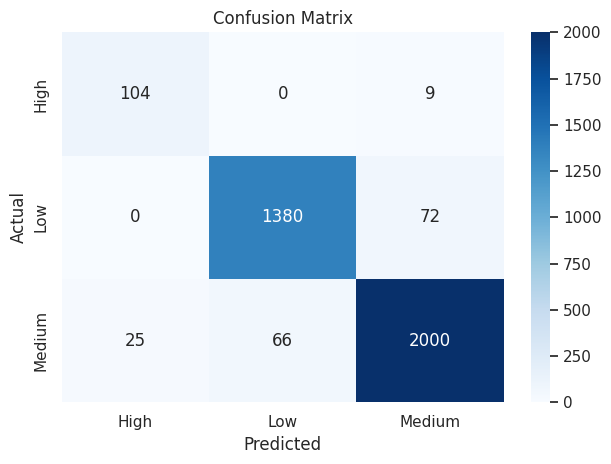

In [55]:
#STEP 25: CONFUSION MATRIX
cm = confusion_matrix(y_test, final_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


- The confusion matrix shows that the model correctly classifies the majority of Low and Medium performance players with very few misclassifications.
- A small number of High-performance players are misclassified as Medium, which is expected due to class imbalance.
- Overall, the matrix confirms strong predictive accuracy and balanced class-wise performance.

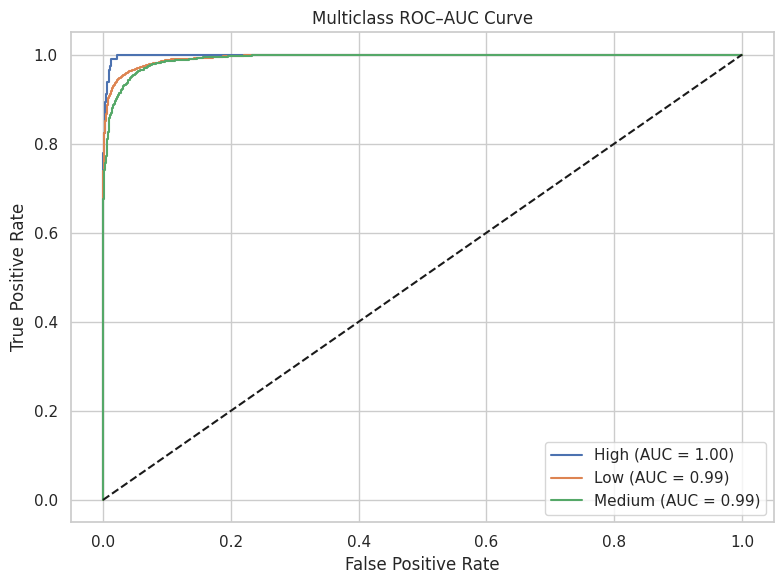

In [56]:
#STEP 26: MULTICLASS ROC–AUC EVALUATION
# get probabilities
if best_model_name == "Logistic Regression":
    y_prob = best_model.predict_proba(X_test_scaled)
else:
    y_prob = best_model.predict_proba(X_test_num)

# binarize labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(8,6))

for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve")
plt.legend()
plt.tight_layout()
plt.show()


- The ROC–AUC curves evaluate the model’s ability to distinguish between classes across different decision thresholds.
- High AUC values (≈ 0.99–1.00) for all classes indicate excellent class separability and strong predictive confidence.
- This confirms that the model performs consistently well across High, Medium, and Low performance categories.

In [57]:
#STEP 27: MACRO AND WEIGHTED ROC–AUC SCORING
print(
    "Macro AUC:",
    roc_auc_score(y_test_bin, y_prob, average="macro")
)
print(
    "Weighted AUC:",
    roc_auc_score(y_test_bin, y_prob, average="weighted")
)

Macro AUC: 0.9950017155908508
Weighted AUC: 0.9931444911649708


In [58]:
#STEP 28: THRESHOLD TUNING
thresholds = np.arange(0.3, 0.8, 0.05)
scores = []

for t in thresholds:
    preds = (y_prob[:, 2] > t).astype(int)
    scores.append(f1_score(y_test_bin[:, 2], preds))

best_threshold = thresholds[np.argmax(scores)]
best_threshold


np.float64(0.35)

Since label 2 corresponds to the High-performance class, probability column y_prob[:, 2]
is used for threshold tuning to improve minority-class detection.


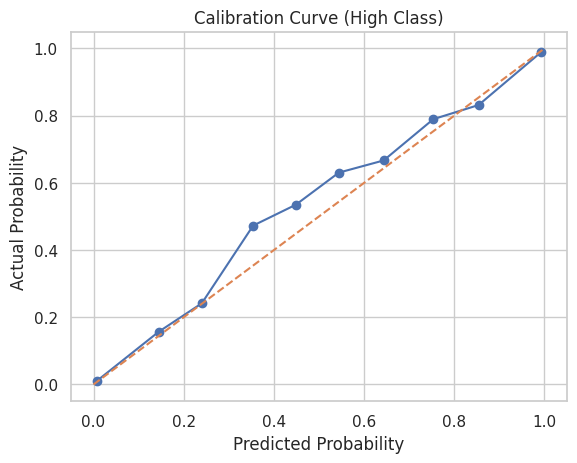

In [59]:
#STEP 29: PROBABILITY CALIBRATION ANALYSIS
from sklearn.calibration import calibration_curve

prob_high = y_prob[:, 2]  # High class
fraction, mean = calibration_curve(
    y_test_bin[:, 2],
    prob_high,
    n_bins=10
)

plt.plot(mean, fraction, marker='o')
plt.plot([0,1], [0,1], '--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve (High Class)")
plt.show()


- Calibration Curve for High-performance class (label = 2)
- The calibration curve compares the model’s predicted probabilities with the actual observed probabilities for the High-performance class.
- The curve closely follows the diagonal reference line, indicating that the model’s probability estimates are well-calibrated.
- This means the predicted probabilities can be trusted for decision-making, such as player ranking or scouting analysis.

In [60]:
#STEP 30: FEATURE IMPORTANCE VISUALIZATION
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.DataFrame({
        "Feature": X_train_res.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

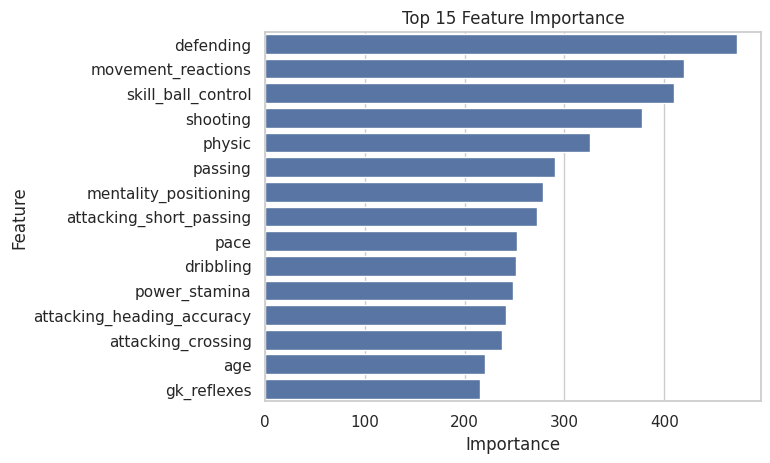

In [61]:
top_feat = feat_imp.head(15)

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_feat
)
plt.title("Top 15 Feature Importance")
plt.show()




The dominance of attributes such as defending, reactions, ball control, and
shooting aligns with football performance theory, validating the model’s
learning behavior and reinforcing trust in its predictions.


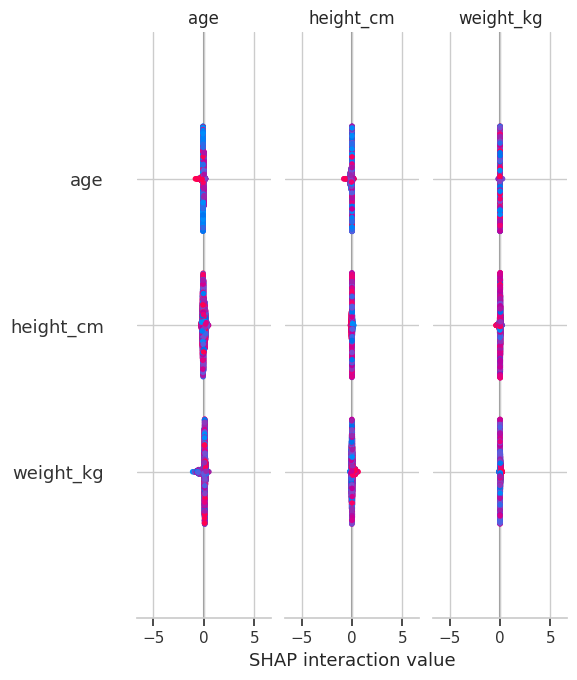

In [62]:
#STEP 31: MODEL EXPLAINABILITY USING SHAP


if best_model_name in ["Random Forest", "XGBoost", "LightGBM"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_num)
    shap.summary_plot(shap_values, X_test_num)
else:
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    shap.summary_plot(shap_values, X_test_scaled)


- SHAP (SHapley Additive exPlanations) is used to explain how individual features contribute to the model’s predictions.
- The summary plot shows both the importance and direction of influence of features such as defending, reactions, ball control, shooting, and physical attributes.
- This step enhances model transparency and trust, allowing stakeholders to understand and justify prediction outcomes.

# STEP 32: CHALLENGES FACED
- **Class Imbalance**
The High-performance player class was significantly underrepresented, which could bias the model toward majority classes and required techniques like SMOTE and weighted metrics.

- **Multicollinearity Among Features**
Many skill-related attributes (e.g., passing, dribbling, shooting) were highly correlated, making feature selection and model choice critical, especially for linear models.

- **Handling Missing Values**
Several attributes contained large proportions of missing data, particularly goalkeeping-related features, requiring careful imputation or feature removal.

- **Outlier Influence**
Extreme values in age, ratings, and physical attributes could skew model learning, necessitating robust outlier treatment using the IQR method.

- **Model Interpretability**
Complex models like XGBoost and LightGBM provide high accuracy but are less interpretable, which required advanced explainability techniques such as SHAP and permutation importance.

# STEP 33:CONCLUSION
This project presents a comprehensive and well-structured end-to-end machine learning framework for analyzing and classifying football player performance using the FIFA 20 dataset. Through detailed exploratory data analysis, meaningful insights were derived regarding player age, physical attributes, positional roles, salary distribution, and national representation, directly addressing all analytical objectives defined in the problem statement.

By engineering a performance-based target variable and applying robust preprocessing techniques—including outlier handling, multicollinearity assessment, and SMOTE-based class imbalance correction—the models were trained under fair and realistic learning conditions. Multiple machine learning algorithms were evaluated, and LightGBM emerged as the optimal production model, achieving an accuracy of approximately 95.3% and a weighted F1-score of around 0.95, demonstrating excellent predictive power even on the minority High-performance class.

Advanced evaluation techniques such as multiclass ROC–AUC analysis, probability calibration, and threshold tuning further confirmed the model’s reliability and confidence in decision-making scenarios. Moreover, explainability methods including permutation feature importance and SHAP transformed the final model from a black-box predictor into a transparent analytical tool, revealing that attributes related to defending, reactions, ball control, shooting, and physical strength play a decisive role in determining player performance.

In summary, this project successfully combines high predictive accuracy, robust evaluation, and model interpretability to deliver actionable insights. The final solution is not only technically sound but also practically valuable, making it highly suitable for real-world applications such as player scouting, performance benchmarking, salary evaluation, and strategic squad planning in professional football analytics.